# Efeito Dominó no Mercado de Transferências
### Análise exploratória
**Objetivo:** Explorar os dados de clubes, jogadores e transferências para identificar sinais brutos do *prêmio do vendedor* e orientar a escolha metodológica.

**Membros:**

1.
2. Leticia Ribeiro Miranda - 2021095686
3. 
4. 

**Estrutura do notebook:**
1. Imports
2. Carga e integração dos dados (JSONL → DataFrame unificado)
3. Limpeza e engenharia de variáveis
4. Análise descritiva das transferências
5. Prêmio bruto: fee vs. valor de mercado
6. Análise do "prêmio do vendedor": clubes que venderam e depois compraram
7. Análise de rede: grafo de transferências
8. Perfil dos jogadores transferidos
9. Conclusões e próximos passos (TP2)

## Imports

In [ ]:
import json
import re
import warnings
import glob  
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import networkx as nx
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data'
clubs_files     = glob.glob(os.path.join(DATA_DIR, '*-clubs.jsonl'))
players_files   = glob.glob(os.path.join(DATA_DIR, '*-players.jsonl'))
transfers_files = glob.glob(os.path.join(DATA_DIR, '*-transfers.jsonl'))
competitions_files = glob.glob(os.path.join(DATA_DIR, '*-competitions.jsonl'))


Clubes carregados: 390 linhas vindas de 21 arquivos.
Jogadores carregados: 11285 linhas vindas de 21 arquivos.
Transferências carregadas: 16215 linhas vindas de 21 arquivos.
Competições carregadas: 1474 linhas vindas de 3 arquivos.


## Carga e integração dos dados (JSONL → DataFrame unificado)

In [12]:
def load_jsonl_to_df(file_list):
    if not file_list:
        print("Aviso: Nenhum arquivo encontrado para o padrão solicitado.")
        return pd.DataFrame()
    
    dfs = []
    for file in file_list:
        with open(file, 'r', encoding='utf-8') as f:
            data = [json.loads(line) for line in f]
        
        df_temp = pd.DataFrame(data)
        
        # Extrai de forma limpa apenas o nome do arquivo (ex: '2023-bundesliga')
        base_name = os.path.basename(file)
        liga_name = (base_name.replace('-transfers.jsonl', '')
                              .replace('-clubs.jsonl', '')
                              .replace('-players.jsonl', '')
                              .replace('-competitions.jsonl', ''))
        
        df_temp['source_league'] = liga_name
        dfs.append(df_temp)
        
    return pd.concat(dfs, ignore_index=True)

df_clubs_raw        = load_jsonl_to_df(clubs_files)
df_players_raw      = load_jsonl_to_df(players_files)
df_transfers_raw    = load_jsonl_to_df(transfers_files)
df_competitions_raw = load_jsonl_to_df(competitions_files)

print(f"Clubes carregados: {df_clubs_raw.shape[0]} linhas vindas de {len(clubs_files)} arquivos.")
print(f"Jogadores carregados: {df_players_raw.shape[0]} linhas vindas de {len(players_files)} arquivos.")
print(f"Transferências carregadas: {df_transfers_raw.shape[0]} linhas vindas de {len(transfers_files)} arquivos.")
print(f"Competições carregadas: {df_competitions_raw.shape[0]} linhas vindas de {len(competitions_files)} arquivos.")

Clubes carregados: 390 linhas vindas de 21 arquivos.
Jogadores carregados: 11285 linhas vindas de 21 arquivos.
Transferências carregadas: 16215 linhas vindas de 21 arquivos.
Competições carregadas: 1474 linhas vindas de 3 arquivos.


In [13]:
# Regras de parsing
def parse_money(s):
    if not isinstance(s, str): return np.nan
    s = s.lower().strip()
    if s in ['loan transfer', '-', 'free transfer', '', 'end of loan']: return np.nan
    s = re.sub(r'loan fee[:\s]*', '', s)
    s = s.replace('€','').replace(',','.').strip()
    mult = 1
    if s.endswith('m'): mult = 1e6; s = s[:-1]
    elif s.endswith('k'): mult = 1e3; s = s[:-1]
    elif s.endswith('bn'): mult = 1e9; s = s[:-1] # Adicionado para tratar valor macro das ligas
    try: return float(s) * mult
    except: return np.nan

def extrair_temporada_e_liga(liga_completa):
    match = re.match(r'^(\d{4})-(.*)$', str(liga_completa))
    if match: return int(match.group(1)), match.group(2)
    return np.nan, liga_completa

# Processando df_clubs
clubs_cleaned = []
for _, c in df_clubs_raw.iterrows():
    ntr_raw = c.get('net_transfer_record', '')
    ntr = re.sub(r'[€+\s]', '', str(ntr_raw)).replace('m', 'e6').replace('k', 'e3')
    try: ntr_val = float(ntr)
    except: ntr_val = np.nan
    
    temporada, comp_code = extrair_temporada_e_liga(c['source_league'])
    
    clubs_cleaned.append({
        'club_name': c.get('name'),
        'club_code': c.get('code'),
        'squad_size': int(c.get('squad_size', 0) or 0),
        'average_age': float(c.get('average_age', 0) or 0),
        'foreigners_pct': float(str(c.get('foreigners_percentage','0')).replace('%','').replace(',','.').strip() or 0),
        'national_team_players': int(c.get('national_team_players', 0) or 0),
        'stadium_seats': int(str(c.get('stadium_seats', '0 Seats')).split()[0].replace('.', '') or 0),
        'net_transfer_record': ntr_val,
        'coach_name': c.get('coach_name', ''),
        'source_league': c['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_clubs = pd.DataFrame(clubs_cleaned)

# Processando df_transfers
def classify_fee(s):
    if not isinstance(s, str): return 'unknown'
    s = s.lower()
    if 'end of loan' in s: return 'end_of_loan'
    if 'loan fee' in s: return 'loan_with_fee'
    if s == 'loan transfer': return 'loan_free'
    if s == 'free transfer': return 'free'
    if s == '-': return 'unknown'
    return 'paid'

def group_position(pos):
    pos = str(pos).lower()
    if 'goalkeeper' in pos: return 'Goalkeeper'
    if 'back' in pos or 'defender' in pos: return 'Defender'
    if 'midfield' in pos: return 'Midfielder'
    if 'winger' in pos or 'forward' in pos or 'striker' in pos or 'attacking' in pos: return 'Attacker'
    return 'Other'

df_transfers = df_transfers_raw.copy()
df_transfers['market_value'] = df_transfers['market_value'].apply(parse_money)
df_transfers['fee_type'] = df_transfers['fee'].apply(classify_fee)
df_transfers['fee_raw'] = df_transfers['fee']
df_transfers['fee'] = df_transfers['fee'].apply(parse_money)
df_transfers['age'] = pd.to_numeric(df_transfers['age'], errors='coerce')

df_transfers['buyer'] = np.where(df_transfers['direction'] == 'In', df_transfers['club'], df_transfers['origin_club'])
df_transfers['seller'] = np.where(df_transfers['direction'] == 'Out', df_transfers['club'], df_transfers['origin_club'])
df_transfers['premium_ratio'] = (df_transfers['fee'] / df_transfers['market_value']) - 1
df_transfers['position_group'] = df_transfers['position'].apply(group_position)

temporadas_t, comp_codes_t = zip(*df_transfers['source_league'].apply(extrair_temporada_e_liga))
df_transfers['season_id'] = temporadas_t
df_transfers['competition_code'] = comp_codes_t

# Proocessando df_players
players_cleaned = []
for _, p in df_players_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(p['source_league'])
    players_cleaned.append({
        'player_id': p.get('player_id', ''),
        'player_code': p.get('code', ''),
        'name': f"{p.get('name','')} {p.get('last_name','')}".strip(),
        'date_of_birth': p.get('date_of_birth', ''),
        'age': pd.to_numeric(p.get('age', None), errors='coerce'),
        'height': p.get('height', ''),
        'citizenship': p.get('citizenship', ''),
        'position': p.get('position', ''),
        'foot': p.get('foot', ''),
        'current_market_value': parse_money(p.get('current_market_value', '')),
        'intl_caps': pd.to_numeric(p.get('international_caps', None), errors='coerce'),
        'intl_goals': pd.to_numeric(p.get('international_goals', None), errors='coerce'),
        'source_league': p['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_players = pd.DataFrame(players_cleaned)

# Processando df_competitions
competitions_cleaned = []
for _, comp in df_competitions_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(comp['source_league'])
    competitions_cleaned.append({
        'competition_name': comp.get('competition_name', ''),
        'competition_type': comp.get('competition_type', ''),
        'country_name': comp.get('country_name', ''),
        'country_code': comp.get('country_code', ''),
        'total_clubs': pd.to_numeric(comp.get('total_clubs', None), errors='coerce'),
        'total_players': pd.to_numeric(comp.get('total_players', None), errors='coerce'),
        'total_value': parse_money(comp.get('total_value', '')),
        'source_league': comp['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_competitions = pd.DataFrame(competitions_cleaned)


# Criando o dataset final de transferências
df_transfers_enriched = df_transfers.merge(
    df_clubs[['club_name', 'source_league', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players']],
    left_on=['club', 'source_league'], 
    right_on=['club_name', 'source_league'], 
    how='left'
).drop(columns=['club_name'])

df_transfers_enriched = df_transfers_enriched.merge(
    df_competitions[['source_league', 'competition_name', 'country_name', 'total_value']],
    on='source_league',
    how='left'
).rename(columns={'total_value': 'league_total_market_value'})


# Exportação dos arquivos consolidados
os.makedirs('../output', exist_ok=True)
df_clubs.to_csv('../output/clubs_consolidated.csv', index=False)
df_players.to_csv('../output/players_consolidated.csv', index=False)
df_transfers.to_csv('../output/transfers_consolidated.csv', index=False)
df_competitions.to_csv('../output/competitions_consolidated.csv', index=False)
df_transfers_enriched.to_csv('../output/transfers_enriched_consolidated.csv', index=False)

print('Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!')

Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!


In [15]:
print('transfers_enriched colunas:', list(df_transfers_enriched.columns))

transfers_enriched colunas: ['type', 'club', 'direction', 'player', 'player_href', 'age', 'nationality', 'position', 'market_value', 'origin_club', 'fee', 'source', 'source_league', 'fee_type', 'fee_raw', 'buyer', 'seller', 'premium_ratio', 'position_group', 'season_id', 'competition_code', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players', 'competition_name', 'country_name', 'league_total_market_value']


## 2. Análise descritiva das transferências

### Pipeline de Pré-processamento e Engenharia de Dados (ETL)

Este bloco de código implementa o pipeline de **Extração, Transformação e Carga (ETL)** para estruturar os dados brutos obtidos via *scraping* do Transfermarkt. O objetivo é converter strings textuais em variáveis numéricas computáveis e gerar duas bases analíticas para investigar o **Efeito Dominó** e o **Prêmio do Vendedor** no mercado de transferências.

---

#### 1. Funções Auxiliares de Parsing
Responsáveis por padronizar as escalas textuais e extrair metadados dos arquivos:
* `parse_money(s)`: Converte valores financeiros textuais (ex: `€95.00m`, `€500k`, `€5.02bn`) em formatos numéricos contínuos (`float`). Transações sem custo imediato (como passes livres e fins de empréstimo) são convertidas em valores nulos (`NaN`).
* `extrair_temporada_e_liga(liga_completa)`: Utiliza expressões regulares para segmentar strings complexas em chaves estruturadas de ano numérico (`season_id`) e identificador da liga (`competition_code`).

---

#### 2. Processamento e Limpeza das Entidades

* **Clubes (`df_clubs`)**: Converte o saldo de mercado (`net_transfer_record`) e taxas de estrangeiros em dados contínuos; limpa capacidades de estádios para inteiros puros; amarra as métricas à sua respectiva janela temporal.
* **Transferências (`df_transfers`)**: 
    * `classify_fee(s)`: Categoriza os tipos de transações - `paid`, `free`, `loan_with_fee`, `loan_free`, `end_of_loan`, `unknown`.
    * `group_position(pos)`: Reduz posições específicas em 4 macro-grupos táticos (*Attacker, Midfielder, Defender, Goalkeeper*).
    * **Derivações de Rede**: Define as colunas estruturais de fluxo direcionado (`buyer` e `seller`) e calcula o **`premium_ratio`** ($\frac{\text{Fee}}{\text{Market Value}} - 1$) para mensurar o valor acima ou abaixo do mercado de cada negociação.
* **Jogadores (`df_players`)**: Junta as colunas de nome e sobrenome em uma única string (name) e padroniza dados demográficos e de histórico internacional (`intl_caps`, `intl_goals`) como inteiros.
* **Competições (`df_competitions`)**: Consolida métricas financeiras macro de mercado por liga e período econômico.

---

#### 3. Cruzamento de Dados e Isolamento Longitudinal
Para construir o ambiente de modelagem final, realizamos um cruzamento de dados (*merge*) unificando a tabela de transações ao contexto de clubes e ligas. 

> **Garantia Metodológica**: O cruzamento adota uma **chave composta** baseada em `['club', 'source_league']`, isso blinda o dataset contra alinhamentos falsos, evitando que métricas de um elenco de 2024 se misturem com transferências de 2023.

---

#### 4. Arquivos Consolidados de Saída (Output)

O pipeline exporta 5 arquivos unificados para a pasta `../output/`:
1.  `clubs_consolidated.csv`: Cadastro histórico limpo dos atributos dos clubes.
2.  `players_consolidated.csv`: Dados cadastrais e de valor de mercado dos atletas.
3.  `competitions_consolidated.csv`: Dados de contexto macroeconômico das ligas.
4.  `transfers_consolidated.csv` **(A Transação Isolada)**: Focado na movimentação do atleta e nos pares de negociação (`buyer` e `seller`). É a base pura de conexões para a **Análise de Redes e Grafos (NetworkX)**.
5.  `transfers_enriched_consolidated.csv` **(O Contexto do Ecossistema)**: O dataset que injeta o histórico financeiro dos clubes envolvidos (`net_transfer_record`) e o patamar econômico da liga correspondente (`league_total_market_value`). É a base para estimar os **Modelos Econométricos e Regressões Causais**.

In [16]:
# Apenas transferências com fee real (pagas)
df_paid = df_transfers[df_transfers['fee_type'] == 'paid'].copy()
print(f'Transferências com fee real: {len(df_paid)}')
print(f'Com market_value informado:  {df_paid["market_value"].notna().sum()}')
print(f'Com ambos fee e MV:          {(df_paid["fee"].notna() & df_paid["market_value"].notna()).sum()}')
print()
print('Estatísticas de fee (€M):')
(df_paid['fee'] / 1e6).describe().round(2)

Transferências com fee real: 4616
Com market_value informado:  4550
Com ambos fee e MV:          4008

Estatísticas de fee (€M):


count    4034.00
mean       10.33
std        15.03
min         0.00
25%         1.50
50%         4.50
75%        13.00
max       145.00
Name: fee, dtype: float64

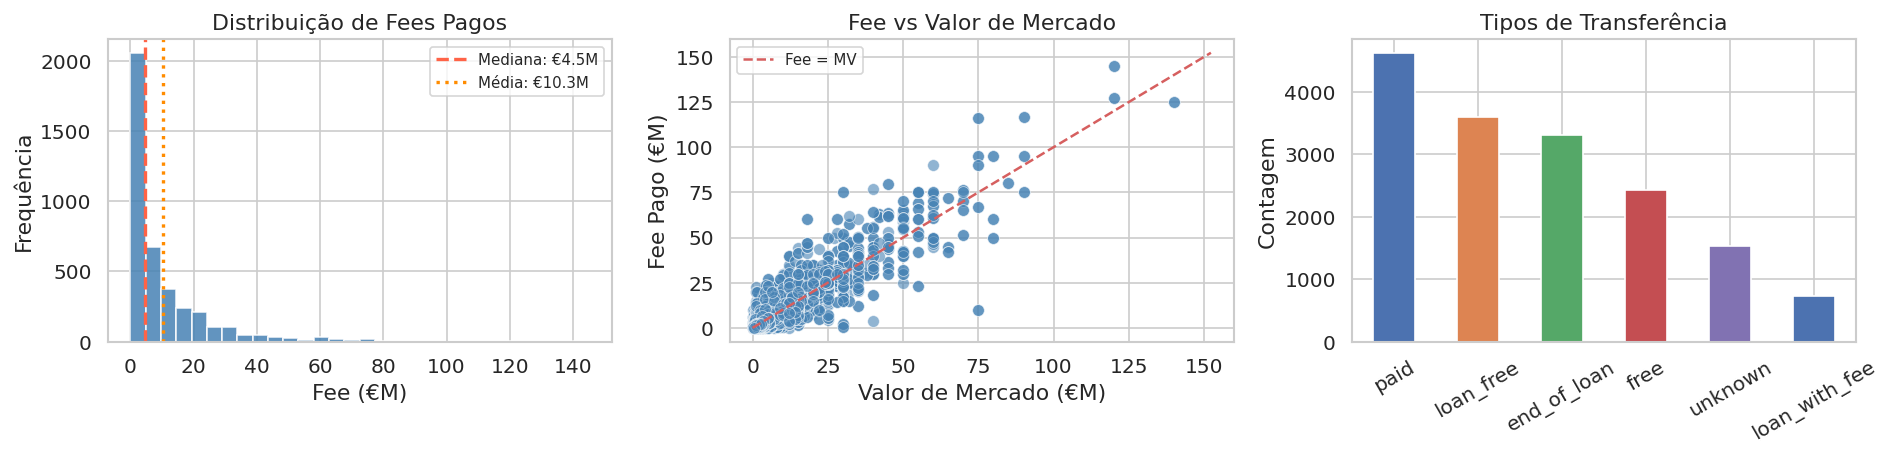

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição de fees pagos
ax = axes[0]
vals = df_paid['fee'].dropna() / 1e6
ax.hist(vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(vals.median(), color='tomato', lw=2, linestyle='--', label=f'Mediana: €{vals.median():.1f}M')
ax.axvline(vals.mean(), color='darkorange', lw=2, linestyle=':', label=f'Média: €{vals.mean():.1f}M')
ax.set_xlabel('Fee (€M)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Fees Pagos')
ax.legend(fontsize=9)

# Fee vs Valor de mercado
ax = axes[1]
df_both = df_paid.dropna(subset=['fee','market_value'])
ax.scatter(df_both['market_value']/1e6, df_both['fee']/1e6,
           alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidths=0.5)
lim = max(df_both[['fee','market_value']].max()) / 1e6 * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Fee = MV')
ax.set_xlabel('Valor de Mercado (€M)')
ax.set_ylabel('Fee Pago (€M)')
ax.set_title('Fee vs Valor de Mercado')
ax.legend(fontsize=9)

# Composição de tipos de transferência
ax = axes[2]
type_counts = df_transfers['fee_type'].value_counts()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
type_counts.plot(kind='bar', ax=ax, color=colors[:len(type_counts)], edgecolor='white')
ax.set_title('Tipos de Transferência')
ax.set_xlabel('')
ax.set_ylabel('Contagem')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()